In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

df = pd.read_csv('../../day02/lab06_clean-dataset/results/secom_clean.csv')

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

df['불량여부'] = (df['result'] == '불량').astype(int)

X = df[sensor_cols]
y = df['불량여부']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = DecisionTreeClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)
예측 = model.predict(X_test)

맞힌양품, 헛경보, 놓친불량, 잡은불량 = confusion_matrix(y_test, 예측).ravel()

print('정확도:', round((예측 == y_test).mean() * 100, 2), '%')
print('잡은 불량:', 잡은불량)
print('놓친 불량:', 놓친불량)
print('헛경보:', 헛경보)

정확도: 88.85 %
잡은 불량: 2
놓친 불량: 19
헛경보: 16


# 실습 11: 조정 다이얼 찾기
- 상황: 모델에는 사람이 정해줘야 하는 값이 있는데, 지금까지 손대지 않고 썼다
- 목표: 그 값을 손으로 돌려보고, 자동 탐색으로 찾아본다

## Step 0. 앞 실습까지 재현하기

## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 사람이 정해주는 값

| 말 | 뜻 |
|---|---|
| 하이퍼파라미터 | 학습으로 정해지지 않고 사람이 미리 정해줘야 하는 값. 설명서에 이 이름으로 나온다 |
| max_depth | 나무가 몇 번까지 갈라질 수 있는지. 스무고개를 몇 번까지 할 것인가 |
| min_samples_leaf | 갈라진 끝자리에 최소 몇 건은 있어야 하는지 |
| 자동 탐색 | 후보를 적어주면 조합마다 다 돌려보고 점수를 재는 것 |
| 기준(scoring) | 자동 탐색이 1등을 뽑을 때 쓰는 자. 정하지 않으면 정확도로 뽑는다 |

## Step 2. 깊이를 손으로 바꿔보기

In [2]:
# 나무 모델과 채점 도구를 불러온다
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score

# 세 가지 깊이를 차례로 넣어본다. None 은 제한 없이 끝까지 간다는 뜻
for 깊이 in [3, 5, None]:
    # max_depth 자리만 바꾸고 나머지는 전부 같게 둔다
    나무 = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=깊이)
    나무.fit(X_train, y_train)
    예측 = 나무.predict(X_test)

    # ravel - 네 칸짜리 표를 한 줄로 펴서 이름을 하나씩 붙여 받는다
    맞힌양품, 헛경보, 놓친불량, 잡은불량 = confusion_matrix(y_test, 예측).ravel()

    print(f"깊이 {깊이}: 정확도 {round((예측 == y_test).mean() * 100, 2)}%",
          f"| 잡은 불량 {잡은불량} 놓친 불량 {놓친불량} 헛경보 {헛경보}",
          f"| 재현율 {round(recall_score(y_test, 예측), 3)}",
          f"F1 {round(f1_score(y_test, 예측), 3)}")

깊이 3: 정확도 48.09% | 잡은 불량 14 놓친 불량 7 헛경보 156 | 재현율 0.667 F1 0.147
깊이 5: 정확도 71.97% | 잡은 불량 10 놓친 불량 11 헛경보 77 | 재현율 0.476 F1 0.185
깊이 None: 정확도 88.85% | 잡은 불량 2 놓친 불량 19 헛경보 16 | 재현율 0.095 F1 0.103


### 문법 노트 - 다이얼 돌리기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| max_depth=3 | 세 번까지만 갈라지게 한다 | 얕게 두면 잘게 외우지 못하고 뭉뚱그려 판단한다 |
| max_depth=None | 제한을 두지 않는다 | 기본값. 답이 나올 때까지 끝까지 갈라진다 |
| random_state=42 | 갈라지는 과정의 무작위 요소를 고정한다 | 다시 돌려도 같은 결과가 나오게 |

## Step 3. 깊이별 결과

| 깊이 | 정확도 | 잡은 불량 | 헛경보 | 재현율 | F1 |
|---|---|---|---|---|---|
| 3 | [48.09]% | [14] | [156] | [0.667] | [0.147] |
| 5 | [71.97]% | [10] | [77] | [0.476] | [0.185] |
| 제한 없음 | [88.85]% | [2] | [16] | [0.095] | [0.103] |

## Step 4. 자동 탐색으로 찾기

In [3]:
# GridSearchCV - 후보 조합마다 학습용 안에서만 교차검증해 점수를 매기고 1등을 뽑는다 (시험용은 쓰지 않는다)
from sklearn.model_selection import GridSearchCV

파라미터_후보 = {
    'max_depth': [2, 3, 4, 5, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
}

탐색 = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    파라미터_후보,
    scoring='recall',
    cv=5,
)

탐색.fit(X_train, y_train)  # 학습용만 사용

print('1등 설정값:', 탐색.best_params_)
print('탐색 중 나온 점수 (재현율, 5겹 교차검증 평균):', round(탐색.best_score_, 3))

# best_estimator_는 1등 설정으로 학습용 전체에 다시 학습시켜 놓은 모델
최고모델 = 탐색.best_estimator_
최고예측 = 최고모델.predict(X_test)

맞힌양품, 헛경보, 놓친불량, 잡은불량 = confusion_matrix(y_test, 최고예측).ravel()

print()
print('[시험용 채점]')
print('정확도:', round((최고예측 == y_test).mean() * 100, 2), '%')
print('잡은 불량:', 잡은불량)
print('놓친 불량:', 놓친불량)
print('헛경보:', 헛경보)
print('재현율:', round(recall_score(y_test, 최고예측, zero_division=0), 3))
print('정밀도:', round(precision_score(y_test, 최고예측, zero_division=0), 3))
print('F1:', round(f1_score(y_test, 최고예측, zero_division=0), 3))

1등 설정값: {'max_depth': 3, 'min_samples_leaf': 20}
탐색 중 나온 점수 (재현율, 5겹 교차검증 평균): 0.53

[시험용 채점]
정확도: 48.09 %
잡은 불량: 14
놓친 불량: 7
헛경보: 156
재현율: 0.667
정밀도: 0.082
F1: 0.147


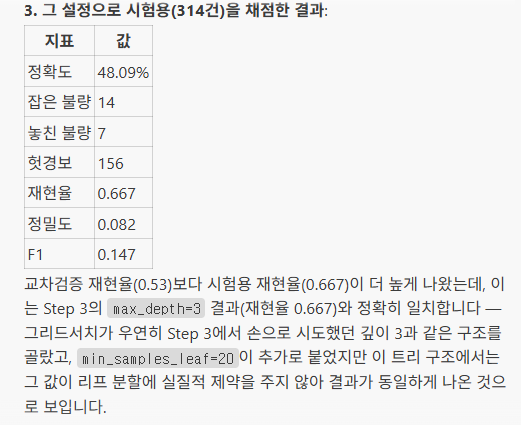

In [4]:
# 방금과 똑같은 후보·모델·cv, 기준(scoring)만 F1로 바꿔서 다시 탐색한다
탐색_F1 = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    파라미터_후보,
    scoring='f1',
    cv=5,
)

탐색_F1.fit(X_train, y_train)  # 학습용만 사용

print('1등 설정값 (F1 기준):', 탐색_F1.best_params_)
print('탐색 중 나온 점수 (F1, 5겹 교차검증 평균):', round(탐색_F1.best_score_, 3))

최고모델_F1 = 탐색_F1.best_estimator_
최고예측_F1 = 최고모델_F1.predict(X_test)

맞힌양품_F1, 헛경보_F1, 놓친불량_F1, 잡은불량_F1 = confusion_matrix(y_test, 최고예측_F1).ravel()

print()
print('[시험용 채점]')
print('정확도:', round((최고예측_F1 == y_test).mean() * 100, 2), '%')
print('잡은 불량:', 잡은불량_F1)
print('놓친 불량:', 놓친불량_F1)
print('헛경보:', 헛경보_F1)
print('재현율:', round(recall_score(y_test, 최고예측_F1, zero_division=0), 3))
print('정밀도:', round(precision_score(y_test, 최고예측_F1, zero_division=0), 3))
print('F1:', round(f1_score(y_test, 최고예측_F1, zero_division=0), 3))

1등 설정값 (F1 기준): {'max_depth': 10, 'min_samples_leaf': 10}
탐색 중 나온 점수 (F1, 5겹 교차검증 평균): 0.192

[시험용 채점]
정확도: 76.75 %
잡은 불량: 6
놓친 불량: 15
헛경보: 58
재현율: 0.286
정밀도: 0.094
F1: 0.141


In [5]:
# 재현율 기준(탐색)과 F1 기준(탐색_F1) 결과를 나란히 놓고 본다
비교표_기준별 = pd.DataFrame([
    {
        '기준': '재현율',
        '설정값': 탐색.best_params_,
        '정확도(%)': round((최고예측 == y_test).mean() * 100, 2),
        '잡은 불량': int(잡은불량),
        '헛경보': int(헛경보),
        '재현율': round(recall_score(y_test, 최고예측, zero_division=0), 3),
        '정밀도': round(precision_score(y_test, 최고예측, zero_division=0), 3),
        'F1': round(f1_score(y_test, 최고예측, zero_division=0), 3),
    },
    {
        '기준': 'F1',
        '설정값': 탐색_F1.best_params_,
        '정확도(%)': round((최고예측_F1 == y_test).mean() * 100, 2),
        '잡은 불량': int(잡은불량_F1),
        '헛경보': int(헛경보_F1),
        '재현율': round(recall_score(y_test, 최고예측_F1, zero_division=0), 3),
        '정밀도': round(precision_score(y_test, 최고예측_F1, zero_division=0), 3),
        'F1': round(f1_score(y_test, 최고예측_F1, zero_division=0), 3),
    },
]).set_index('기준')

비교표_기준별

,설정값,정확도(%),잡은 불량,헛경보,재현율,정밀도,F1
기준,,,,,,,
재현율,"{'max_depth': 3, 'min_samples_leaf': 20}",48.09,14,156,0.667,0.082,0.147
F1,"{'max_depth': 10, 'min_samples_leaf': 10}",76.75,6,58,0.286,0.094,0.141


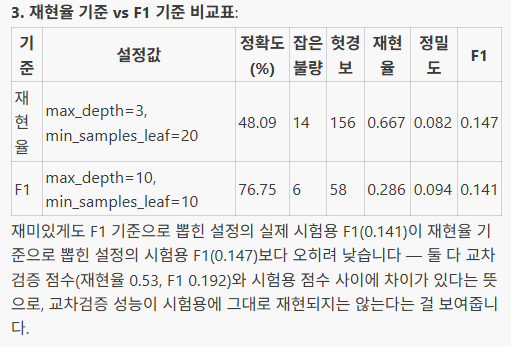

## Step 5. 기준을 바꾸면 1등이 바뀐다

| 뽑은 기준 | 1등 설정 | 정확도 | 잡은 불량 | 헛경보 | 재현율 | F1 |
|---|---|---|---|---|---|---|
| 재현율 | [max_depth=3, min_samples_leaf=20] | [48.09]% | [14] | [156] | [0.667] | [0.147] |
| F1 | [max_depth=10, min_samples_leaf=10] | [76.75]% | [6] | [58] | [0.286] | [0.141] |

## Step 6. 내가 고른 설정

- 고른 기준 : [F1] - [놓친 불량도 줄이고 싶지만 헛경보 156건은 현장에서 감당이 안 될 것 같아서]
- 고른 설정 : [max_depth=10, min_samples_leaf=10]
- 이 설정의 시험용 성적 : [정확도 76.75% / 재현율 0.286 / 정밀도 0.094 / F1 0.141]

---
## 직접 해보기 (도전) - 다른 모델에도 다이얼이 있다

- 상황: 나무에만 다이얼이 있는 게 아니다
- 할 일: 로지스틱 회귀의 다이얼 하나를 네 값으로 돌려보고, 자동 탐색과 견줘본다
- 결과물: 네 줄짜리 표 1개 + 한 줄 메모

### 로지스틱 회귀의 하이퍼파라미터

의사결정나무의 `max_depth`·`min_samples_leaf`처럼, 로지스틱 회귀에도 사람이 미리 정해줘야 하는 값들이 있다.

| 말 | 뜻 |
|---|---|
| C | 규제(regularization)의 세기를 반대로 뒤집어 나타낸 값. 작을수록 규제가 세져서 계수를 작게 억누르고, 클수록 규제가 약해져서 계수가 자유로워진다 |
| penalty | 규제를 어떤 방식으로 거는지 (기본은 L2) |
| solver | 계수를 찾는 계산 방법 (알고리즘 종류) |
| max_iter | 계산을 최대 몇 번 반복할지 |
| class_weight | 드문 쪽을 얼마나 무겁게 셀지 (Step 2에서 이미 씀) |

여기서는 `C`만 바꾸고 나머지(`max_iter=1000`, `class_weight="balanced"`)는 고정한다.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

C_후보 = [0.01, 0.1, 1, 10]

결과_C = []
for C값 in C_후보:
    로지스틱모델 = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C값, max_iter=1000, class_weight="balanced")
    )
    로지스틱모델.fit(X_train, y_train)  # 학습용으로 학습
    예측_C = 로지스틱모델.predict(X_test)  # 시험용으로 채점

    맞힌양품_C, 헛경보_C, 놓친불량_C, 잡은불량_C = confusion_matrix(y_test, 예측_C).ravel()

    결과_C.append({
        'C': C값,
        '정확도(%)': round((예측_C == y_test).mean() * 100, 2),
        '잡은 불량': int(잡은불량_C),
        '헛경보': int(헛경보_C),
        '재현율': round(recall_score(y_test, 예측_C, zero_division=0), 3),
        '정밀도': round(precision_score(y_test, 예측_C, zero_division=0), 3),
        'F1': round(f1_score(y_test, 예측_C, zero_division=0), 3),
    })

C_비교표 = pd.DataFrame(결과_C).set_index('C')
C_비교표

,정확도(%),잡은 불량,헛경보,재현율,정밀도,F1
C,,,,,,
0.01,75.16,13,70,0.619,0.157,0.250
0.10,73.57,10,72,0.476,0.122,0.194
1.00,74.84,10,68,0.476,0.128,0.202
10.00,73.89,10,71,0.476,0.123,0.196


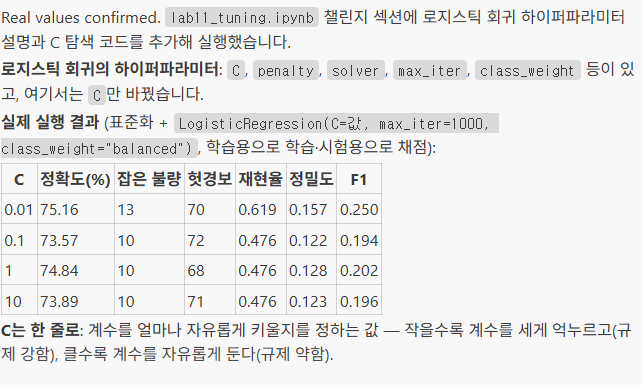